In [9]:
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

from sklearn.metrics import classification_report
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [10]:
DATASET_PATH = "/kaggle/input/datasets/nikitarom/planets-dataset/planet/planet"

CSV_PATH = os.path.join(
    DATASET_PATH,
    "train_classes.csv"
)

IMAGE_DIR = os.path.join(
    DATASET_PATH,
    "train-jpg"
)

OUTPUT_DIR = "/kaggle/working/outputs"

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

TABLE_DIR = os.path.join(
    OUTPUT_DIR,
    "tables"
)

MODEL_DIR = os.path.join(
    OUTPUT_DIR,
    "models"
)

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print(os.path.exists(CSV_PATH))
print(os.path.exists(IMAGE_DIR))

True
True


In [11]:
df = pd.read_csv(CSV_PATH)

df["tags"] = df["tags"].apply(
    lambda x: x.split(" ")
)

mlb = MultiLabelBinarizer()

encoded_labels = mlb.fit_transform(
    df["tags"]
)

label_names = mlb.classes_

label_df = pd.DataFrame(
    encoded_labels,
    columns=label_names
)

dataset_df = pd.concat(
    [
        df["image_name"],
        label_df
    ],
    axis=1
)

print(dataset_df.shape)

display(dataset_df.head())

(40479, 18)


,image_name,agriculture,artisinal_mine,bare_ground,blooming,blow_down,clear,cloudy,conventional_mine,cultivation,habitation,haze,partly_cloudy,primary,road,selective_logging,slash_burn,water
0,train_0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0
1,train_1,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,train_2,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
3,train_3,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,train_4,1,0,0,0,0,1,0,0,0,1,0,0,1,1,0,0,0


In [12]:
train_df, temp_df = train_test_split(
    dataset_df,
    test_size=0.30,
    random_state=42
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

print("Training:", len(train_df))
print("Validation:", len(valid_df))
print("Testing:", len(test_df))

Training: 28335
Validation: 6072
Testing: 6072


In [13]:
IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(image_name):

    image_path = os.path.join(
        IMAGE_DIR,
        image_name + ".jpg"
    )

    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = image.astype(np.float32)

    image = image / 255.0

    return image

In [14]:
class PlanetDataGenerator(
    tf.keras.utils.Sequence
):

    def __init__(
        self,
        dataframe,
        batch_size=32,
        shuffle=True
    ):

        self.dataframe = dataframe.reset_index(drop=True)

        self.batch_size = batch_size

        self.shuffle = shuffle

        self.indexes = np.arange(
            len(self.dataframe)
        )

        self.on_epoch_end()

    def __len__(self):

        return int(
            np.floor(
                len(self.dataframe) /
                self.batch_size
            )
        )

    def __getitem__(
        self,
        index
    ):

        indexes = self.indexes[
            index*self.batch_size:
            (index+1)*self.batch_size
        ]

        batch_df = self.dataframe.iloc[indexes]

        images = []

        labels = []

        for _, row in batch_df.iterrows():

            image = load_image(
                row["image_name"]
            )

            label = row.iloc[1:].values.astype(
                np.float32
            )

            images.append(image)

            labels.append(label)

        return (
            np.array(images),
            np.array(labels)
        )

    def on_epoch_end(self):

        if self.shuffle:

            np.random.shuffle(
                self.indexes
            )

train_generator = PlanetDataGenerator(
    train_df,
    batch_size=BATCH_SIZE
)

valid_generator = PlanetDataGenerator(
    valid_df,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = PlanetDataGenerator(
    test_df,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Generators Ready")

Generators Ready


In [15]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.15
    ),

    tf.keras.layers.RandomZoom(
        0.15
    )

])

base_model = tf.keras.applications.ResNet50(

    include_top=False,

    weights="imagenet",

    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(224,224,3)
)

x = data_augmentation(
    inputs
)

x = tf.keras.applications.resnet50.preprocess_input(
    inputs * 255.0
)

x = base_model(
    x,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(
    0.4
)(x)

x = tf.keras.layers.Dense(
    512,
    activation="relu"
)(x)

outputs = tf.keras.layers.Dense(
    len(label_names),
    activation="sigmoid"
)(x)

resnet50_model = tf.keras.Model(
    inputs,
    outputs
)

resnet50_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Multiply)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ multiply_1[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ multiply_1[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ multiply_1[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │  1,049,088 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 17)        │      8,721 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,645,521 (94.02 MB)

 Trainable params: 1,057,809 (4.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [16]:
resnet50_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="binary_accuracy"
        )
    ]
)

early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.3,

    patience=2
)

history = resnet50_model.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=1,

    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

885/885 ━━━━━━━━━━━━━━━━━━━━ 2666s 3s/step - binary_accuracy: 0.9522 - loss: 0.1260 - val_binary_accuracy: 0.9593 - val_loss: 0.1063 - learning_rate: 0.0010


In [17]:
print("HELLO")

HELLO


In [18]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [19]:
print("Notebook is responsive")

Notebook is responsive


In [20]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [21]:
resnet50_model.save(

    os.path.join(
        MODEL_DIR,
        "resnet50_model.keras"
    )
)

print("ResNet50 Saved")

ResNet50 Saved


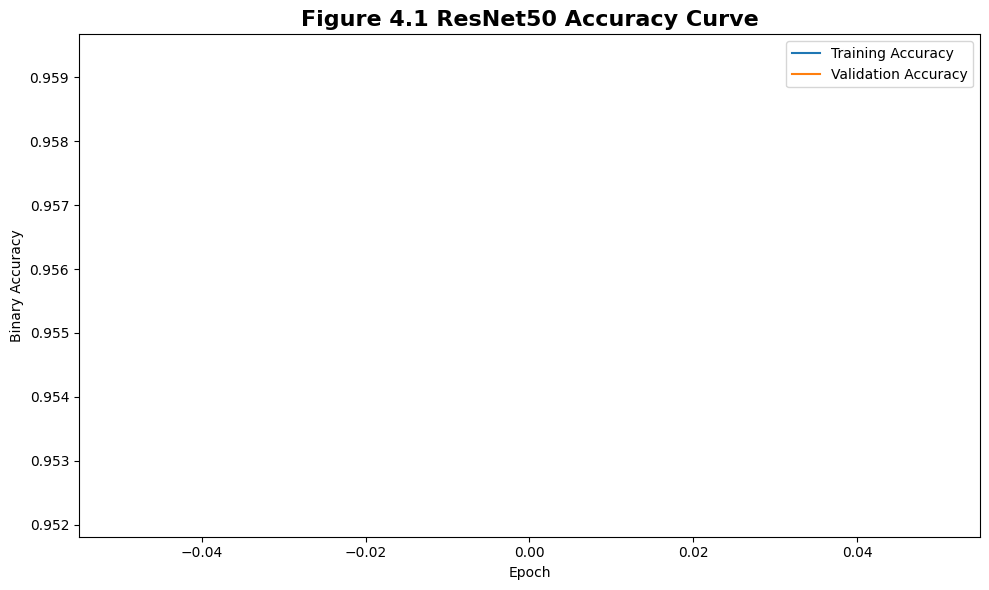

In [22]:
plt.figure(figsize=(10,6))

plt.plot(
    history.history["binary_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_binary_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Figure 4.1 ResNet50 Accuracy Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epoch")

plt.ylabel("Binary Accuracy")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "resnet50_accuracy_curve.pdf"
    )
)

plt.show()

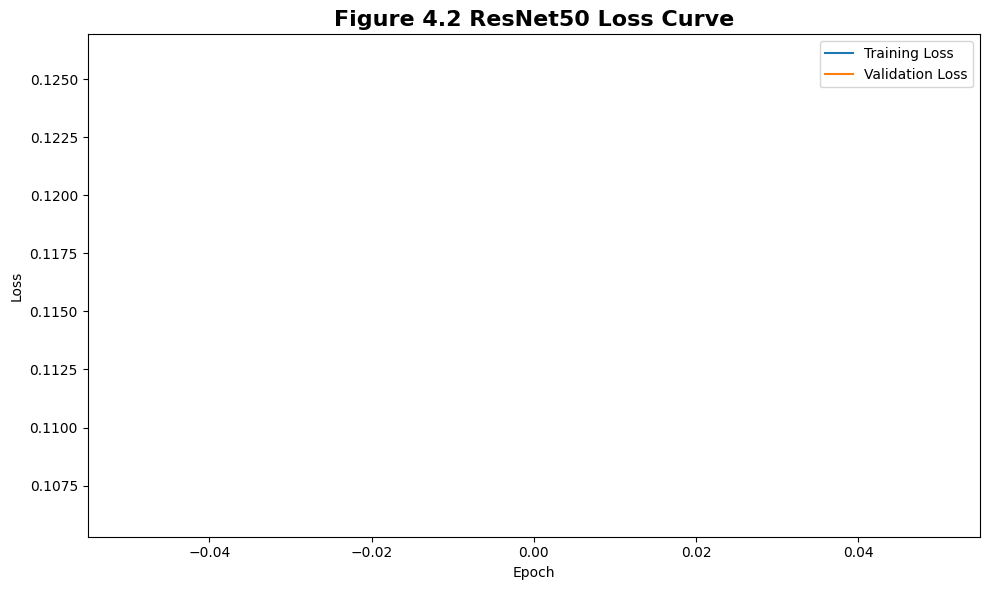

In [23]:
plt.figure(figsize=(10,6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Figure 4.2 ResNet50 Loss Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "resnet50_loss_curve.pdf"
    )
)

plt.show()

In [24]:
results = resnet50_model.evaluate(
    test_generator
)

metrics_df = pd.DataFrame({

    "Metric": resnet50_model.metrics_names,

    "Value": results

})

metrics_df.to_csv(

    os.path.join(
        TABLE_DIR,
        "resnet50_metrics.csv"
    ),

    index=False
)

metrics_df

189/189 ━━━━━━━━━━━━━━━━━━━━ 459s 2s/step - binary_accuracy: 0.9593 - loss: 0.1062


,Metric,Value
0,loss,0.106190
1,compile_metrics,0.959316


In [25]:
predictions = resnet50_model.predict(
    test_generator
)

y_pred = (
    predictions > 0.5
).astype(int)

y_true = []

for _, labels in test_generator:

    y_true.extend(labels)

y_true = np.array(y_true)

report = classification_report(

    y_true,

    y_pred,

    target_names=label_names,

    output_dict=True
)

report_df = pd.DataFrame(
    report
).transpose()

report_df.to_csv(

    os.path.join(
        TABLE_DIR,
        "resnet50_classification_report.csv"
    )
)

report_df.head()

189/189 ━━━━━━━━━━━━━━━━━━━━ 466s 2s/step


,precision,recall,f1-score,support
agriculture,0.846252,0.722648,0.779581,1828.0
artisinal_mine,0.882353,0.652174,0.750000,46.0
bare_ground,0.586207,0.117241,0.195402,145.0
blooming,0.000000,0.000000,0.000000,52.0
blow_down,0.000000,0.000000,0.000000,10.0


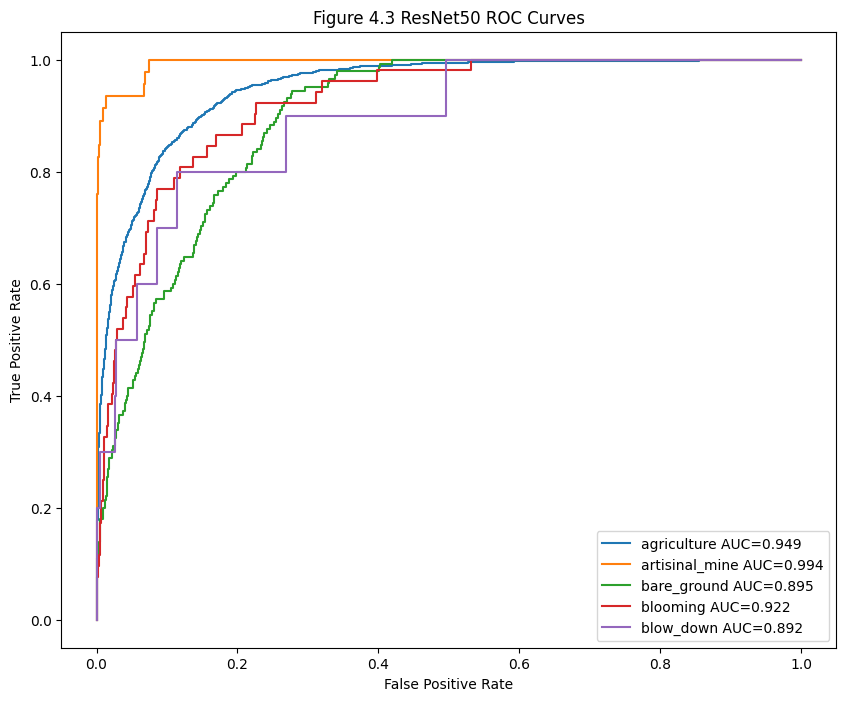

In [26]:
plt.figure(figsize=(10,8))

for i in range(5):

    fpr, tpr, _ = roc_curve(
        y_true[:,i],
        predictions[:,i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{label_names[i]} AUC={roc_auc:.3f}"
    )

plt.title(
    "Figure 4.3 ResNet50 ROC Curves"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "resnet50_roc_curve.pdf"
    )
)

plt.show()

In [27]:
confusion_matrices = multilabel_confusion_matrix(

    y_true,

    y_pred
)

print(
    confusion_matrices.shape
)

print("="*70)
print("NOTEBOOK 4 COMPLETED SUCCESSFULLY")
print("="*70)

print("""
Generated Outputs

resnet50_model.keras

resnet50_accuracy_curve.pdf

resnet50_loss_curve.pdf

resnet50_roc_curve.pdf

resnet50_metrics.csv

resnet50_classification_report.csv
""")

(17, 2, 2)
NOTEBOOK 4 COMPLETED SUCCESSFULLY

Generated Outputs

resnet50_model.keras

resnet50_accuracy_curve.pdf

resnet50_loss_curve.pdf

resnet50_roc_curve.pdf

resnet50_metrics.csv

resnet50_classification_report.csv

